<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


<h1><center>Final Assignment</center></h1>


> ***Note: Please ensure you follow the instructions outlined in the in the <a href="https://www.coursera.org/learn/supervised-machine-learning-regression/supplement/YGZt9/project-scenario">Project Scenario</a> section to complete this Final Assignment successfully.***


***Section 1- Data Summary***

Downloaded from kaggle.com ,this dataset originates from the 1990 California Census and is widely used as an introductory machine learning dataset, featured in Aurélien Géron's Hands-On Machine Learning with Scikit-Learn and TensorFlow.

Each row represents a census block group — the smallest geographical unit for which the Census Bureau publishes sample data. Block groups typically contain 600 to 3,000 people.

With a total entry : 20640

Original Features : 10

Missing Value : 207

Mean House Value : $206.856

Census Cap or Max House Value : $500,001

1.1 Feature Descriptions


1.   longitude :Block group longitude coordinate. Range: −124.35 to −114.31

2.   latitude: Block group latitude coordinate. Range: 32.54 to 41.95

3. housing_median_age: Median age of houses in the block group (years). Range: 1–52

4. total_room :Total number of rooms in all households. Heavily right-skewed.

5. total_bedrooms: Total bedrooms. 207 missing values — imputed with median.

6. population: Total block group population. Lognormal distribution.

7. households: Number of households (groups sharing a home unit).

8. median_income: Median household income in $10,000s. Strongest predictor.

9. ocean_proximity: Categorical: <1H OCEAN, INLAND, NEAR OCEAN, NEAR BAY, ISLAND.

10. median_house_value : **Target variable**. Median house value in USD. Capped at $500,001.





***Objective of the Analysis***


1.   Predict median house values:
     Build regression models that estimate a district's median house value from its socioeconomic and geographic characteristics, benchmarked on a held-out test set.

2.   Identify key price drivers:
     Quantify which features most strongly influence house prices and characterise the direction and magnitude of their effects.

3.   Compare model variants:
     Evaluate plain OLS linear regression against regularised variants (Ridge, Lasso, ElasticNet) and a polynomial extension, selecting the best model based on test R², RMSE, and cross-validation stability.
     



    



# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.

In [ ]:
#!pip install -U scikit-learn
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn

In [ ]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import Normalizer

###Uploading files directly

In [ ]:
from google.colab import files

print("Please select your file(s) to upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')



Please select your file(s) to upload:


Saving housing.csv to housing (1).csv
User uploaded file "housing (1).csv" with length 1423529 bytes


###Reading our data

In [ ]:
with open('housing.csv', 'r') as f:
  data = pd.read_csv(f)
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
data.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [ ]:
data.shape

(20640, 10)

In [ ]:
data.dtypes.value_counts()

,count
float64,9
object,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


***Section 3 - Exploratory Data Analysis***

### 3.1- Duplicates & Missing Values

In [ ]:
#check Duplicates
duplicates = data.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

Duplicate rows found: 0


There is no duplicates found.

In [ ]:
total = data.isnull().sum().sort_values(ascending=False)
print(total)

total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


Text(0.5, 1.0, 'Total Missing Values')

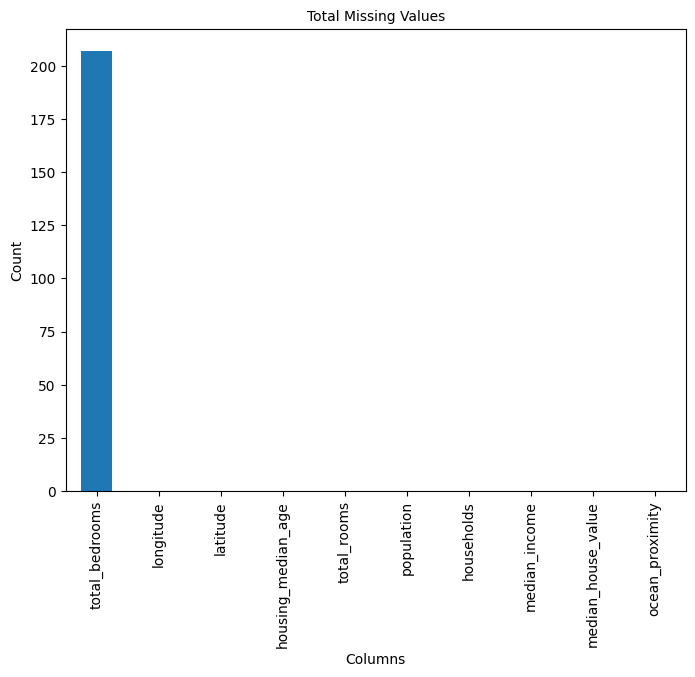

In [ ]:
total_select = total.head(10)
total_select.plot(kind="bar", figsize = (8,6), fontsize = 10)

plt.xlabel("Columns", fontsize = 10)
plt.ylabel("Count", fontsize = 10)
plt.title("Total Missing Values", fontsize = 10)

With only 207 missing out of 20,640 rows (1.0%), this is a very small proportion.

Volume → 1.0% missing → low → safe to impute
Mechanism

## 3.2 - Correlation Analysis & Target Distribution

In [ ]:
# Print ALL correlations with ChurnScore
median_house__num = data.select_dtypes(include=['float64', 'int64'])
median_house__num_corr = median_house__num.corr()['median_house_value'].drop('median_house_value')

print(median_house__num_corr.sort_values(ascending=False))

median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [ ]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
new_data = data[['longitude', 'latitude','housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']]

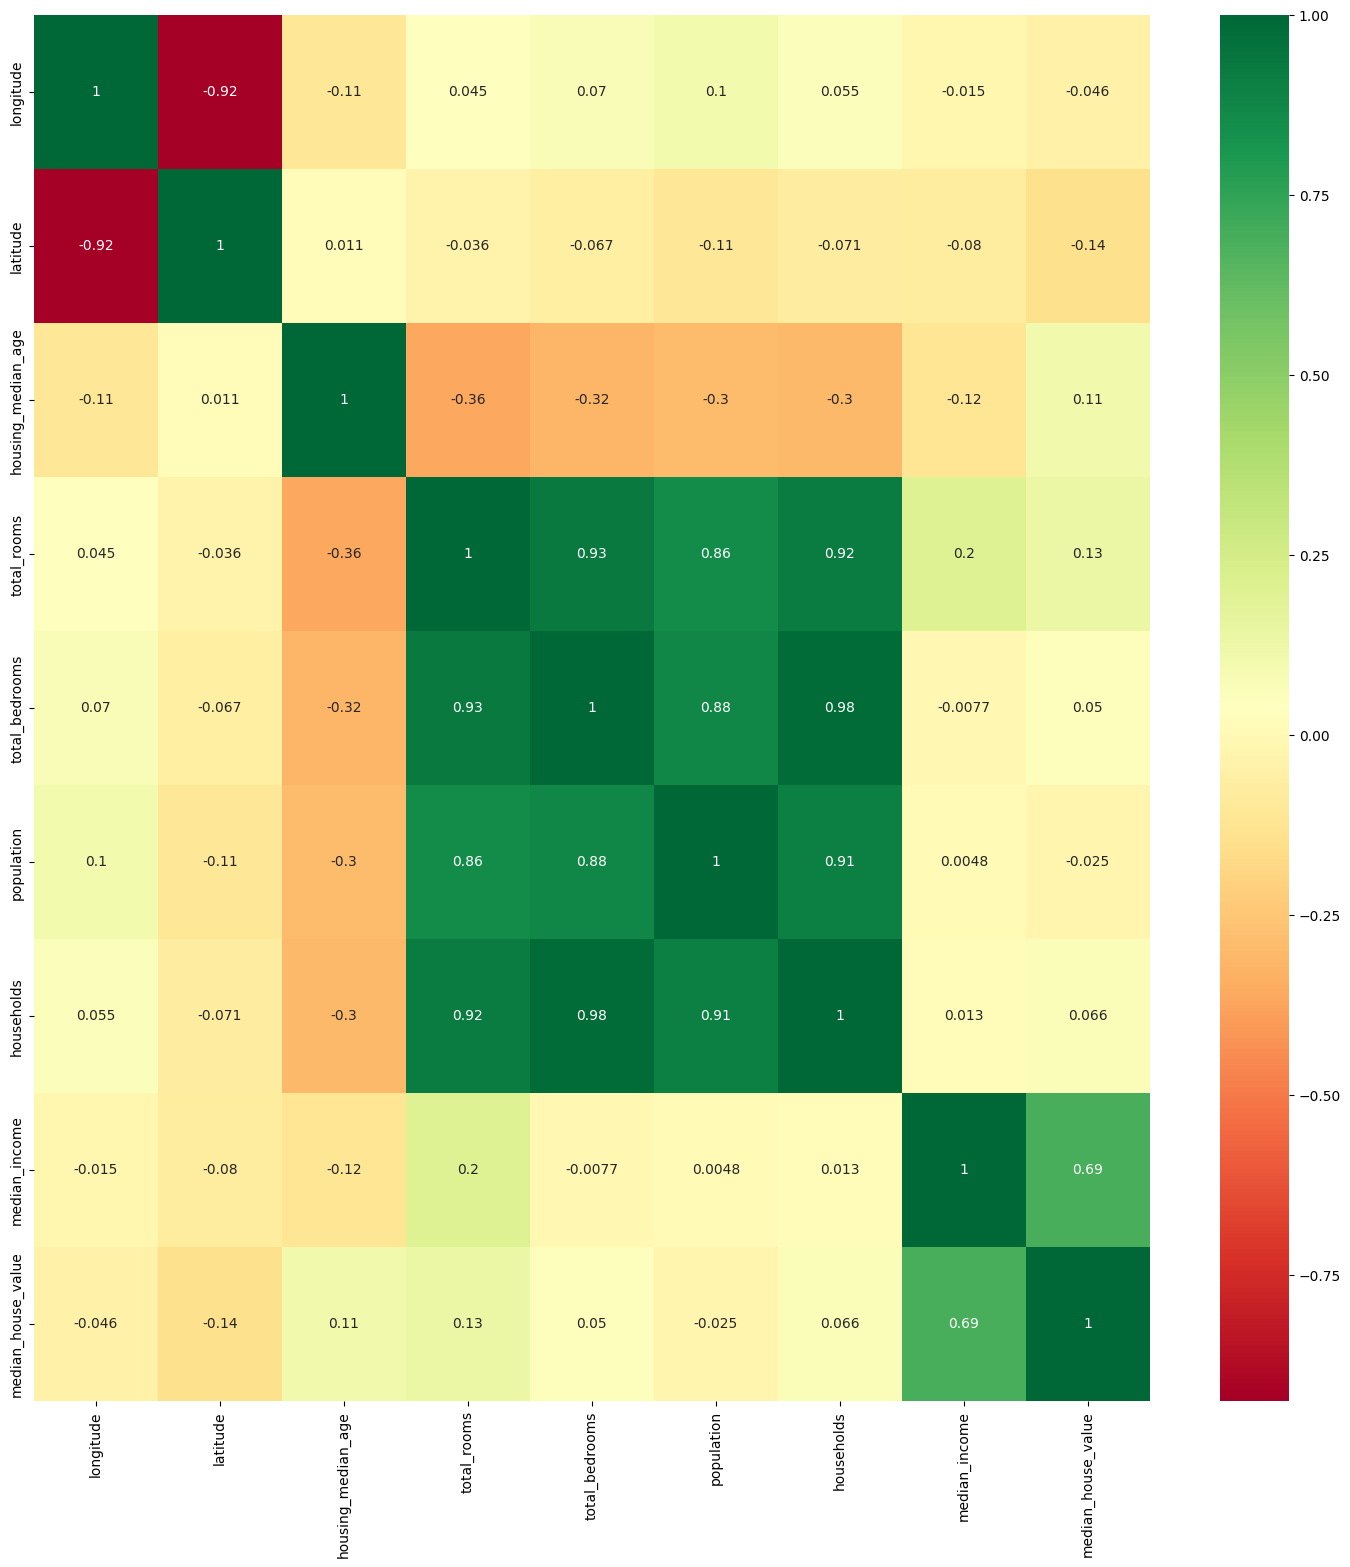

In [ ]:
# This code shows the correlation between the features
plt.figure(figsize=(18,18))
sns.heatmap(new_data.select_dtypes(include=['number']).corr(),annot=True,cmap='RdYlGn')

plt.show()

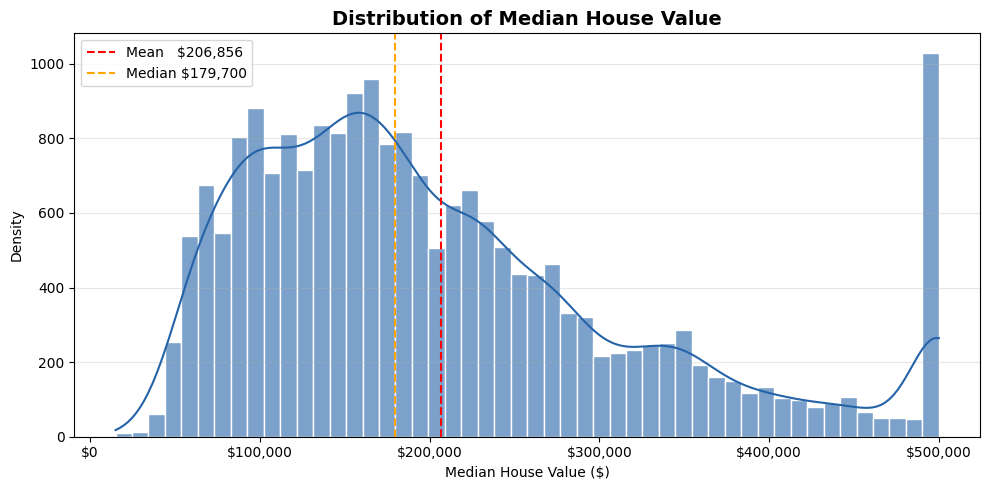

In [ ]:


fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(data['median_house_value'], bins=50, kde=True,
             color='#2563a8', edgecolor='white', alpha=0.6, ax=ax)

ax.axvline(data['median_house_value'].mean(),
           color='red', linestyle='--', linewidth=1.5,
           label=f"Mean   ${data['median_house_value'].mean():,.0f}")
ax.axvline(data['median_house_value'].median(),
           color='orange', linestyle='--', linewidth=1.5,
           label=f"Median ${data['median_house_value'].median():,.0f}")

ax.set_title('Distribution of Median House Value', fontsize=14, fontweight='bold')
ax.set_xlabel('Median House Value ($)')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

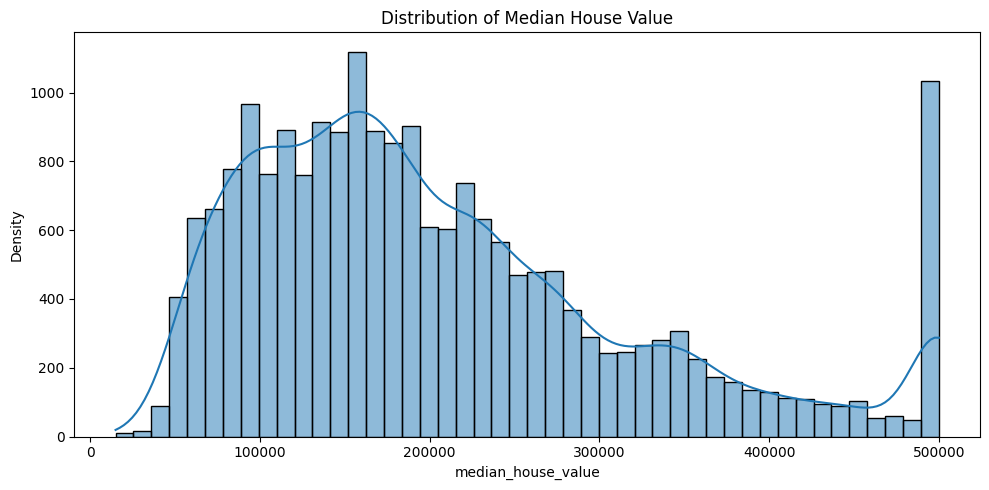

In [ ]:

#import seaborn as sns
#import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(data['median_house_value'], kde=True, ax=ax)

ax.set_title('Distribution of Median House Value')
ax.set_xlabel('median_house_value')
ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

In [ ]:
print(f"Skewness: {data['median_house_value'].skew():.2f}")

Skewness: 0.98


**median_income** is the single variable most correlated with the target (r ≈ 0.69), far exceeding all other features. total_rooms and households show strong mutual collinearity (r ≈ 0.92), motivating the engineered features rooms_per_household and bedrooms_per_room to distil their independent signal.
The target distribution is right-skewed with a sharp spike at 500,001,a census artifact where all values above
$500k were
capped. This ceiling affects ~2% of observations and will cause models to systematically under-predict for the most expensive districts.

##3.3 - Geographic Distribution

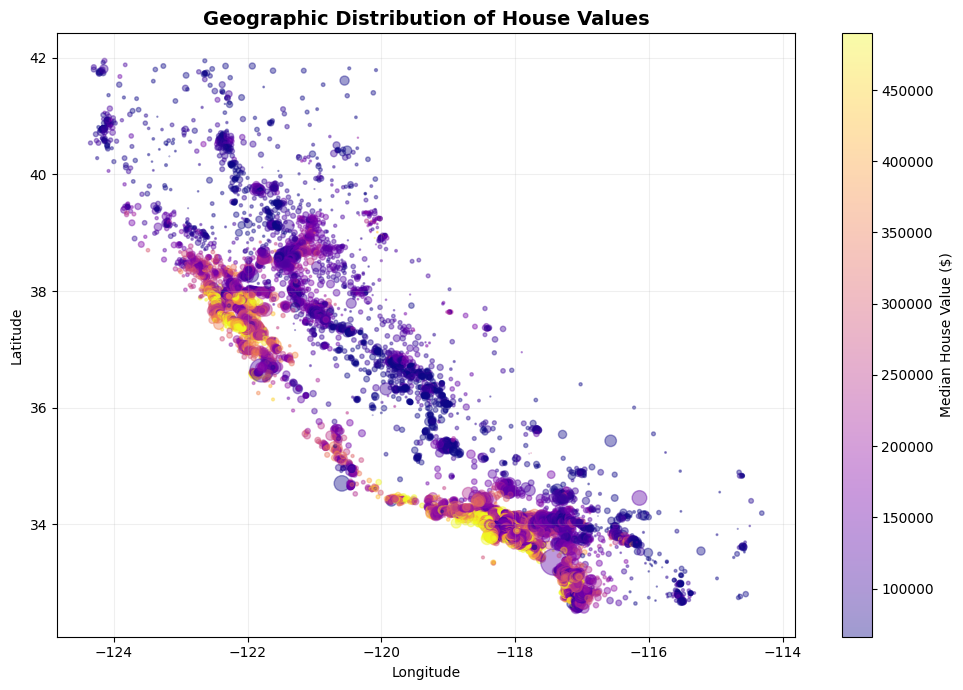

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    data['longitude'],
    data['latitude'],
    c=data['median_house_value'],
    s=data['population'] / 100,        # size = population
    cmap='plasma',
    alpha=0.4,
    vmin=data['median_house_value'].quantile(0.05),
    vmax=data['median_house_value'].quantile(0.95)
)

plt.colorbar(scatter, ax=ax, label='Median House Value ($)')
ax.set_title('Geographic Distribution of House Values', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Mapping values geographically reveals two dominant spatial gradients:The two bright yellow clusters at latitude ≈ 37.8 (San Francisco Bay Area) and latitude ≈ 34.0 (Los Angeles) are clearly the most expensive regions ,this is the coastal premium visible in the data. The diagonal spine of points follows the California coastline, and the sparse inland points (Central Valley, around longitude −119 to −120) are mostly dark purple, confirming significantly lower house values away from the coast.
This spatial autocorrelation means geographic coordinates carry significant predictive value beyond what pure income data captures.

House Value by Ocean Proximity

Comparison between median_house_value vs ocean_proximity

In [ ]:

print(data.groupby('ocean_proximity')['median_house_value'].describe().round(0))

                  count      mean       std       min       25%       50%  \
ocean_proximity                                                             
<1H OCEAN        9136.0  240084.0  106124.0   17500.0  164100.0  214850.0   
INLAND           6551.0  124805.0   70008.0   14999.0   77500.0  108500.0   
ISLAND              5.0  380440.0   80560.0  287500.0  300000.0  414700.0   
NEAR BAY         2290.0  259212.0  122819.0   22500.0  162500.0  233800.0   
NEAR OCEAN       2658.0  249434.0  122477.0   22500.0  150000.0  229450.0   

                      75%       max  
ocean_proximity                      
<1H OCEAN        289100.0  500001.0  
INLAND           148950.0  500001.0  
ISLAND           450000.0  450000.0  
NEAR BAY         345700.0  500001.0  
NEAR OCEAN       322750.0  500001.0  


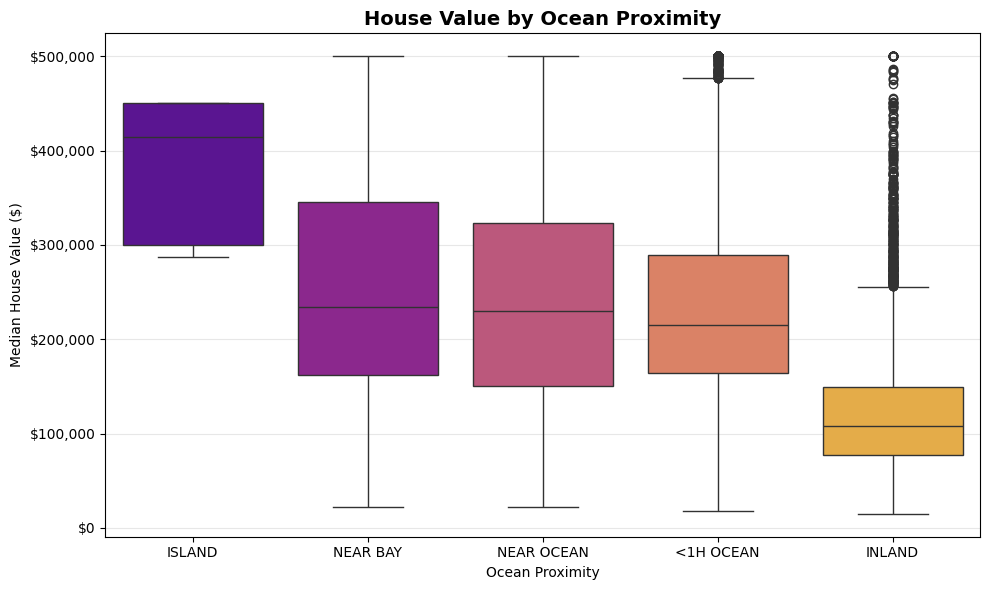

In [ ]:


fig, ax = plt.subplots(figsize=(10, 6))
order = data.groupby('ocean_proximity')['median_house_value'] \
            .median().sort_values(ascending=False).index
sns.boxplot(data=data, x='ocean_proximity', y='median_house_value',
            order=order, palette='plasma', ax=ax)
ax.set_title('House Value by Ocean Proximity', fontsize=14, fontweight='bold')
ax.set_xlabel('Ocean Proximity')
ax.set_ylabel('Median House Value ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Districts near the bay or ocean command a substantial premium over inland areas. The NEAR BAY category anchoring the San Francisco metro, shows the tightest distribution and highest median, while INLAND districts exhibit the widest spread and lowest values.

***Section 4 -Preprocessing***

In [ ]:
# Keep original intact
data_original = data.copy()

In [ ]:
data_log = data.copy()
data_log['median_house_value'] = np.log(data_log['median_house_value'])

In [ ]:
print(f"Original skewness: {data_original['median_house_value'].skew():.2f}")
print(f"Log skewness:      {data_log['median_house_value'].skew():.2f}")

Original skewness: 0.98
Log skewness:      -0.17


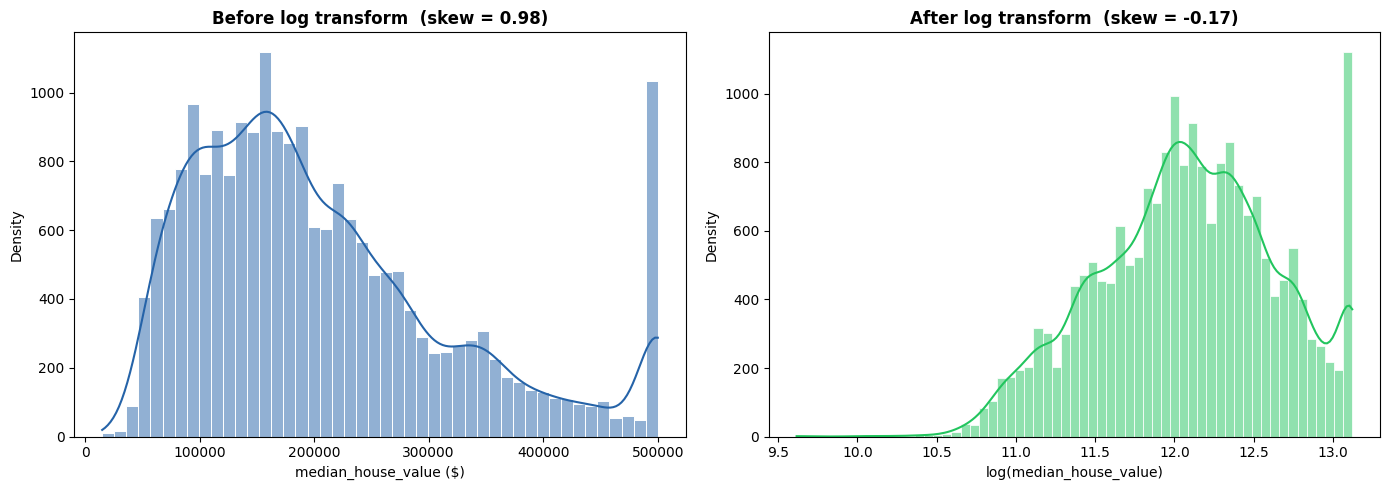

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
sns.histplot(data_original['median_house_value'], kde=True,
             color='#2563a8', edgecolor='white', ax=axes[0])
axes[0].set_title(f'Before log transform  (skew = {data_original["median_house_value"].skew():.2f})',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('median_house_value ($)')
axes[0].set_ylabel('Density')

# After
sns.histplot(data_log['median_house_value'], kde=True,
             color='#22c55e', edgecolor='white', ax=axes[1])
axes[1].set_title(f'After log transform  (skew = {data_log["median_house_value"].skew():.2f})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(median_house_value)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

Original skewness: 0.98 → moderately right-skewed, long tail toward expensive properties

Log skewness: −0.17 → nearly symmetric, well within the acceptable range

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

In [ ]:
# Define features and target
X = data_log.drop(columns=['median_house_value'])
y = data_log['median_house_value']

In [ ]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures:\n{X.columns.tolist()}")

X shape: (20640, 9)
y shape: (20640,)

Features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']


Encoding the Object type feature ocean_proximity & Split the data

In [ ]:
# Encode categorical column
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)
# Split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (16512, 12)
X_test:  (4128, 12)
y_train: (16512,)
y_test:  (4128,)


In [ ]:
print("number of test samples :", X_test.shape[0])
print("number of training samples:",X_train.shape[0])

number of test samples : 4128
number of training samples: 16512


In [ ]:
print(X_train.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


***Section 5 - Model Comparison***

##5.1- Linear Regression

In [ ]:
# Create a LinearRegression object, called lm.
lm = LinearRegression()
# Fit the model with multiple features on our X_train and y_train data.
lm.fit(X_train, y_train)


LinearRegression()

Create a pipeline to handle missing values by imputing the median in total_bedrooms

In [ ]:
# Pipeline handles imputation automatically before fitting
lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LinearRegression())
])

lr_pipe.fit(X_train, y_train)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

In [ ]:
predicted = lr_pipe.predict(X_test)

Calculate  the R^2 on both, training and testing data sets.

In [ ]:
print(f"R² Train: {lr_pipe.score(X_train, y_train):.4f}")
print(f"R² Test: {lr_pipe.score(X_test,  y_test):.4f}")

R² Train: 0.6684
R² Test: 0.6498


Plot a distribution of the predicted values vs actual values

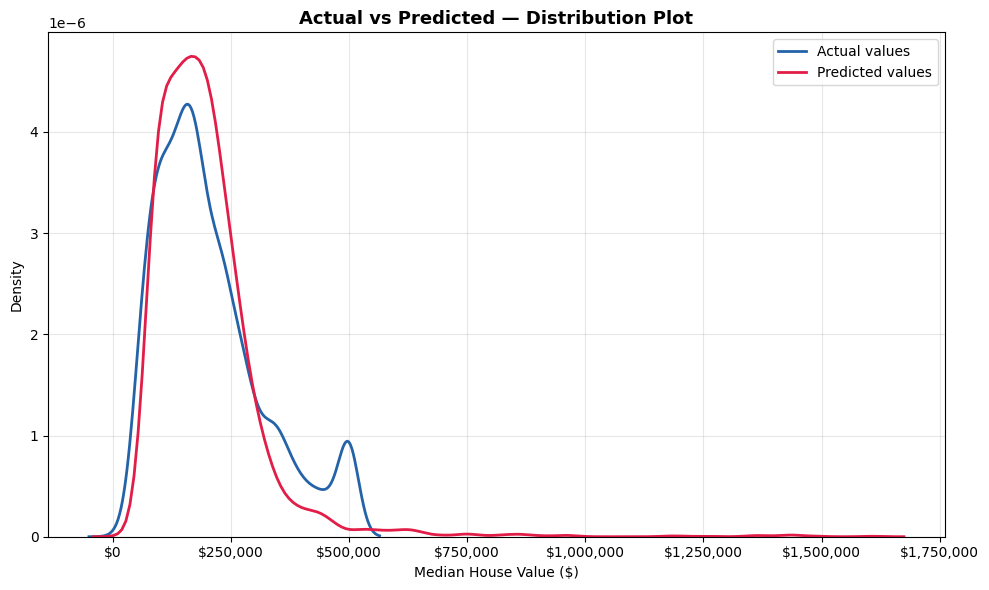

In [ ]:
#import matplotlib.pyplot as plt
#import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(np.exp(y_test),      label='Actual values',    color='#2563a8', linewidth=2, ax=ax)
sns.kdeplot(np.exp(predicted),   label='Predicted values', color='#e11d48', linewidth=2, ax=ax)

ax.set_title('Actual vs Predicted — Distribution Plot', fontsize=13, fontweight='bold')
ax.set_xlabel('Median House Value ($)')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Summary of findings:

**Observation & Interpretation**

- Peaks align at ~$175k:
 Model captures average districts well

- Predicted curve narrower:
Model under-estimates variance — safe but conservative

- Misses $500k bump:
Census cap makes high-value districts unpredictable

- Tail extends to $1.75M:
Log back-transform amplifies errors at extremes

In [ ]:
# Extract coefficients
coef_df = pd.DataFrame({
    'Feature':     X_train.columns.tolist(),
    'Coefficient': lr_pipe.named_steps['model'].coef_
})

# Sort by absolute value
coef_df = coef_df.reindex(
    coef_df['Coefficient'].abs().sort_values(ascending=False).index
)

print("── Linear Regression Coefficients ──")
print(coef_df.to_string(index=False))

── Linear Regression Coefficients ──
                   Feature  Coefficient
                  latitude    -0.340300
                 longitude    -0.328420
             median_income     0.323337
                population    -0.199103
            total_bedrooms     0.160166
    ocean_proximity_INLAND    -0.141226
                households     0.102022
        housing_median_age     0.033326
               total_rooms    -0.029138
  ocean_proximity_NEAR BAY    -0.013507
ocean_proximity_NEAR OCEAN    -0.012558
    ocean_proximity_ISLAND     0.008427


In [ ]:
{col:coef for col,coef in zip(X_train, lr_pipe.named_steps['model'].coef_)}

{'longitude': np.float64(-0.3284202693736032),
 'latitude': np.float64(-0.3403000814099141),
 'housing_median_age': np.float64(0.03332619767729203),
 'total_rooms': np.float64(-0.029137639481017913),
 'total_bedrooms': np.float64(0.16016613042202443),
 'population': np.float64(-0.1991027713695958),
 'households': np.float64(0.10202226182982702),
 'median_income': np.float64(0.32333719557694646),
 'ocean_proximity_INLAND': np.float64(-0.14122613110808188),
 'ocean_proximity_ISLAND': np.float64(0.008426670377082213),
 'ocean_proximity_NEAR BAY': np.float64(-0.013507162336505285),
 'ocean_proximity_NEAR OCEAN': np.float64(-0.012558228173365545)}

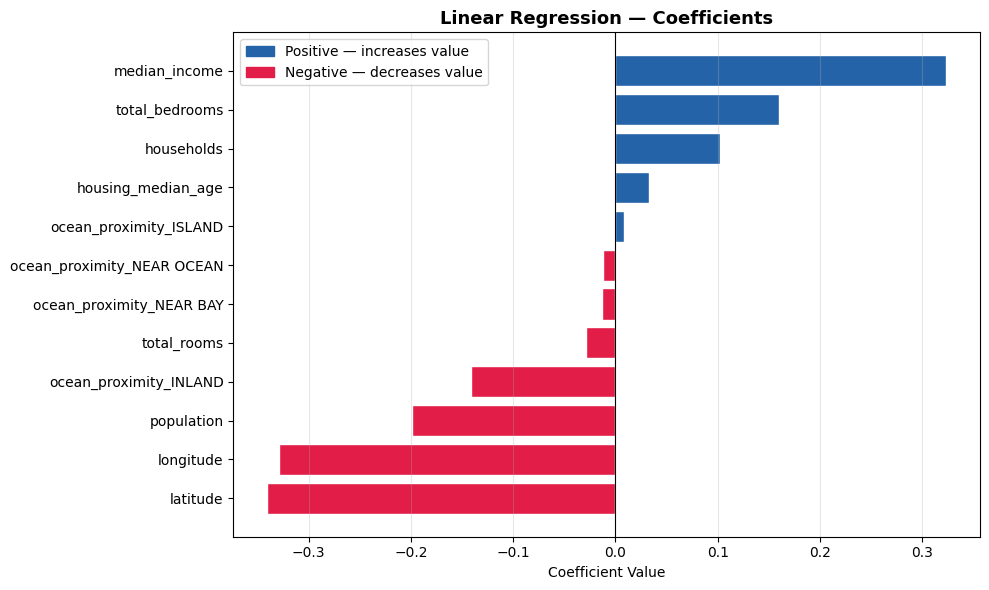

In [ ]:
# Sort by value to see positive and negative clearly
coef_df = coef_df.sort_values('Coefficient', ascending=True)

# Plot with sign
colors = ['#e11d48' if c < 0 else '#2563a8' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression — Coefficients', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='#2563a8', label='Positive — increases value'),
    Patch(color='#e11d48', label='Negative — decreases value')
])

plt.tight_layout()
plt.show()

Three key insights:

1. Geography dominates latitude and longitude together are the strongest predictors, confirming the coastal premium seen in the geographic distribution plot. The model has essentially learned that being close to the coast and in Southern California drives prices up.
2. total_bedrooms positive but total_rooms negative , this is the collinearity effect we discussed. When both are in the model together, total_bedrooms gets credit for increasing value while total_rooms goes negative to compensate. This is exactly why engineered features like rooms_per_household would be more stable.
3. ocean_proximity_NEAR BAY is slightly negative , surprising since Bay Area properties are expensive. This happens because latitude and longitude are already capturing the geographic premium  once location coordinates are controlled for, the NEAR BAY category adds little extra signal.

##5.2 - Ridge Regression

In [ ]:
# Ridge Regression Pipeline
ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   Ridge(alpha=1))
])

ridge_pipe.fit(X_train, y_train)

# R² scores
print("── Ridge Regression ──")
print(f"R² Train: {ridge_pipe.score(X_train, y_train):.4f}")
print(f"R² Test:  {ridge_pipe.score(X_test,  y_test):.4f}")

── Ridge Regression ──
R² Train: 0.6684
R² Test:  0.6499


Alpha=1 is too small to make a meaningful difference on this dataset — the regularisation penalty is not strong enough to shrink the coefficients noticeably yet

Try different alpha to see the suitable one.

In [ ]:


for alpha in [1, 10, 100, 500, 1000]:
    ridge = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   Ridge(alpha=alpha))
    ])
    ridge.fit(X_train, y_train)
    print(f"α={alpha:<6} R² Train: {ridge.score(X_train, y_train):.4f}  "
          f"R² Test: {ridge.score(X_test, y_test):.4f}")

α=1      R² Train: 0.6684  R² Test: 0.6499
α=10     R² Train: 0.6684  R² Test: 0.6500
α=100    R² Train: 0.6677  R² Test: 0.6508
α=500    R² Train: 0.6623  R² Test: 0.6483
α=1000   R² Train: 0.6561  R² Test: 0.6439


1. Best alpha is around 100 — test R² peaks at 0.6508 then starts declining. The optimal value is somewhere between 100 and 500.
2. Ridge reduces overfitting — notice the gap between train and
 test R² shrinks as alpha increases:

   α=1   → gap = 0.0185   (more overfit)

   α=100 → gap = 0.0169   (less overfit)  ← sweet spot

   α=1000→ gap = 0.0101   (underfit)

3. Overall R² is moderate (~0.65) — both Linear and Ridge explain about 65% of variance. This suggests the relationship is not purely linear — which is why we'll also test Lasso and polynomial features later.

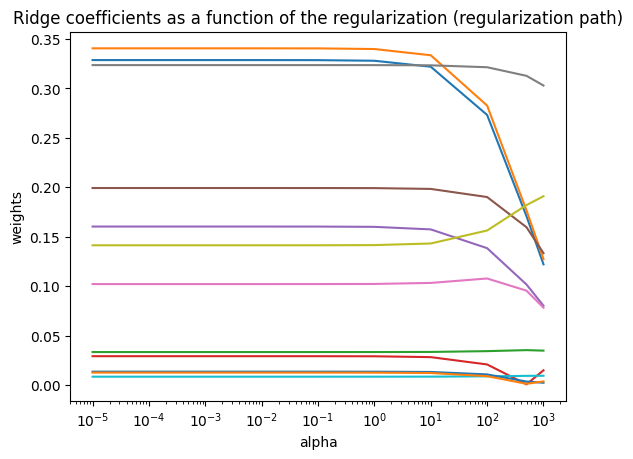

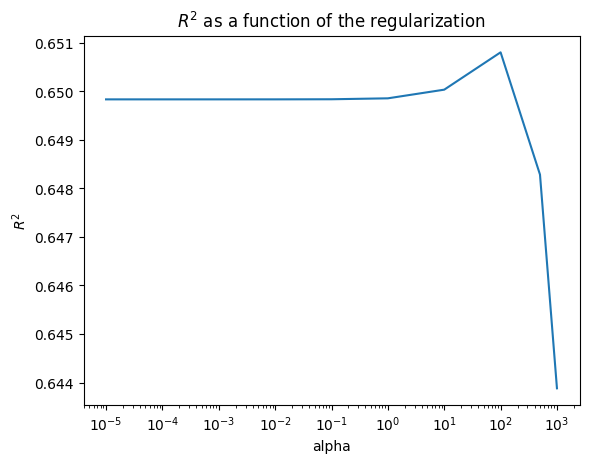

In [ ]:
alphas = [0.00001,0.0001,0.001,0.01,0.1,1,10,100,500,1000]
R_2=[]
coefs = []
for alpha in alphas:
    ridge_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   Ridge(alpha=alpha))
    ])
    ridge_pipeline.fit(X_train, y_train)
    coefs.append(abs(ridge_pipeline.named_steps['model'].coef_))
    R_2.append(ridge_pipeline.score(X_test,y_test))


ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Ridge coefficients as a function of the regularization (regularization path)")
plt.show()


ax = plt.gca()
ax.plot(alphas, R_2)
ax.set_xscale("log")
plt.xlabel("alpha")
plt.ylabel("$R^2$")
plt.title("$R^2$ as a function of the regularization")
plt.show()

Plot the MSE as a function of alpha.

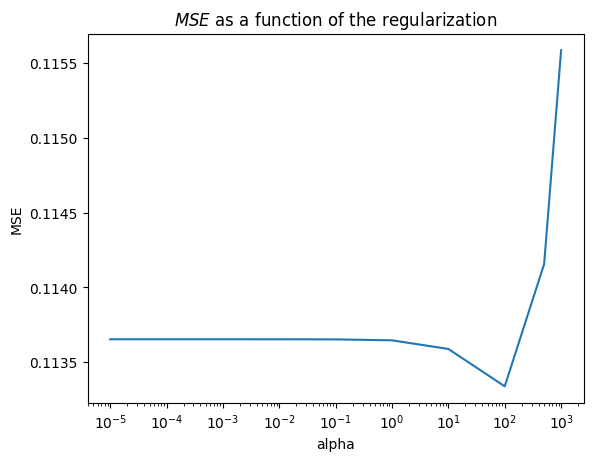

In [ ]:
alphas = [0.00001,0.0001,0.001,0.01,0.1,1,10,100,500,1000]
MEAN_SQE=[]

for alpha in alphas:
    ridge_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   Ridge(alpha=alpha))
    ])
    ridge_pipeline.fit(X_train, y_train)
    MEAN_SQE.append(mean_squared_error(ridge_pipeline.predict(X_test),y_test))

ax = plt.gca()
ax.plot(alphas, MEAN_SQE)
ax.set_xscale("log")
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.title("$MSE$ as a function of the regularization")
plt.show()

α < 10    → MSE ≈ 0.1137  (flat — Ridge = Linear Regression)

α = 100   → MSE = 0.1133  (minimum — best alpha)  ✓

α > 100   → MSE rises sharply to 0.1156

 Ridge model with α=100 and compare coefficients with Linear Regression

── Final Ridge (α=100) ──
R² Train: 0.6677
R² Test:  0.6508


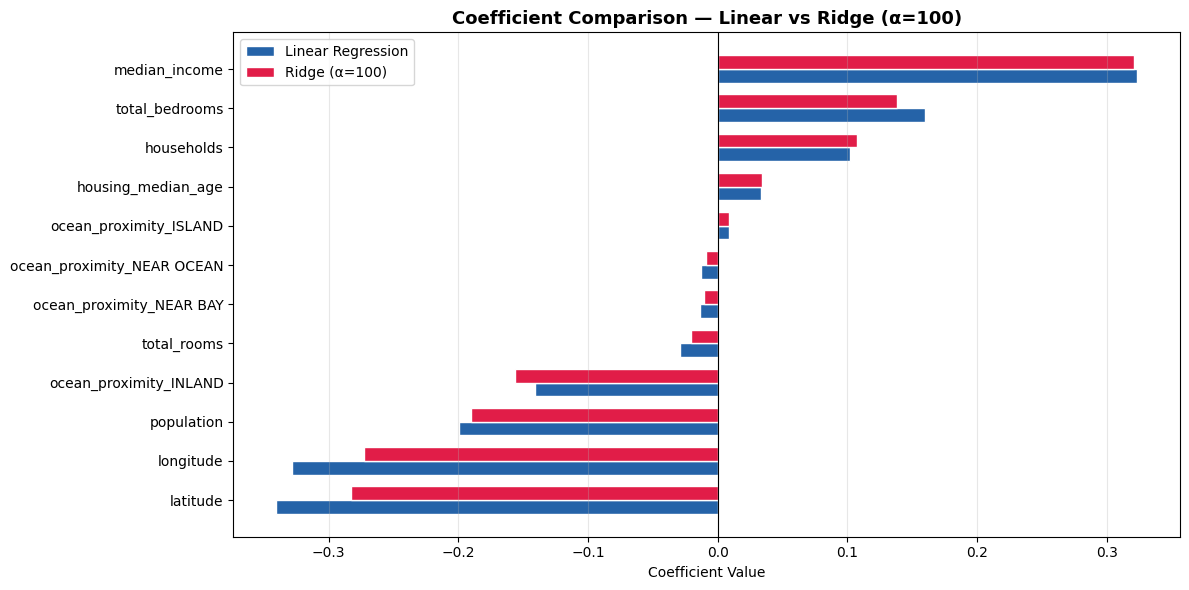

In [ ]:
# Final Ridge with best alpha
ridge_best = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   Ridge(alpha=100))
])
ridge_best.fit(X_train, y_train)

print("── Final Ridge (α=100) ──")
print(f"R² Train: {ridge_best.score(X_train, y_train):.4f}")
print(f"R² Test:  {ridge_best.score(X_test,  y_test):.4f}")

# Compare coefficients
coef_compare = pd.DataFrame({
    'Feature':           X_train.columns.tolist(),
    'Linear Regression': lr_pipe.named_steps['model'].coef_,
    'Ridge (α=100)':     ridge_best.named_steps['model'].coef_
}).sort_values('Linear Regression', ascending=True)

# Plot side by side
fig, ax = plt.subplots(figsize=(12, 6))
x     = np.arange(len(coef_compare))
width = 0.35

ax.barh(x - width/2, coef_compare['Linear Regression'], width,
        label='Linear Regression', color='#2563a8', edgecolor='white')
ax.barh(x + width/2, coef_compare['Ridge (α=100)'],     width,
        label='Ridge (α=100)',     color='#e11d48', edgecolor='white')

ax.set_yticks(x)
ax.set_yticklabels(coef_compare['Feature'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coefficient Comparison — Linear vs Ridge (α=100)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Ridge vs Linear — key takeaways:

✓ R² improvement: +0.0009 (modest but consistent)

✓ Coefficients shrunk toward zero — more stable model

✓ Geography (lat/lon) shrunk most — were slightly inflated in
  Linear

✓ median_income unchanged — confirms it as the true dominant    predictor

✓ No coefficient eliminated — Ridge shrinks but never zeros out

Model Comparison (Polynomial - Ridge - Regression) - Pipelining & GridSearch

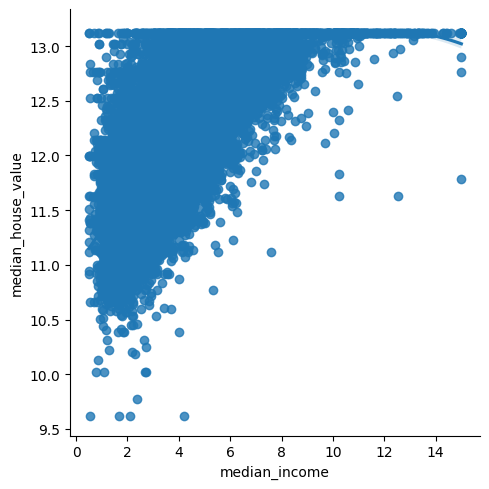

In [ ]:
sns.lmplot(x = 'median_income', y = 'median_house_value', data = data_log, order=2)

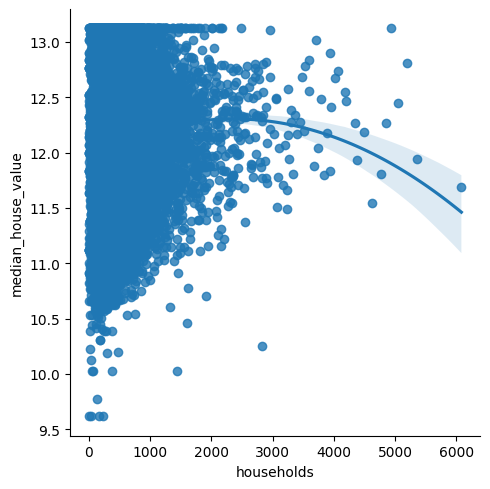

In [ ]:
sns.lmplot(x = 'households', y = 'median_house_value', data = data_log, order=2)

Based on the 2 plots , we can also say there is non-linearity between the feature households, median income and median house value.
That justify the polynomial model .

In [ ]:

print(f"Features after polynomial: {PolynomialFeatures(degree=2, include_bias=False).fit_transform(X_train).shape[1]}")

Features after polynomial: 90


Pipeline

In [ ]:
# Pipeline
ridge_poly_pipe = Pipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('polynomial', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler',     StandardScaler()),
    ('model',      Ridge(alpha=1))
])

GridSearchCV

In [ ]:
# GridSearch
param_grid_ridge = {"polynomial__degree": [1,2,3],'model__alpha': np.logspace(-3, 4, 50)}


In [ ]:
grid_ridge = GridSearchCV(ridge_poly_pipe, param_grid_ridge,cv=5,scoring='r2', n_jobs=-1,verbose=1)

grid_ridge.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('polynomial',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('model', Ridge(alpha=1))]),
             n_jobs=-1,
             param_grid={'model__alpha': array([1.00000000e-03, 1.38949549e-03, 1.93069773e-03, 2.68269580e-03,
       3.72759372e-03, 5.17947468e-03, 7.19685673e-03, 1.0...
       1.00000000e+01, 1.38949549e+01, 1.93069773e+01, 2.68269580e+01,
       3.72759372e+01, 5.17947468e+01, 7.19685673e+01, 1.00000000e+02,
       1.38949549e+02, 1.93069773e+02, 2.68269580e+02, 3.72759372e+02,
       5.17947468e+02, 7.19685673e+02, 1.00000000e+03, 1.38949549e+03,
       1.93069773e+03, 2.68269580e+03, 3.72759372e+03, 5.17947468e+03,
       7.19685673e+03, 1.00000000e+04]),
                         'polynomial__degree': [1, 2, 3]},
             scoring='r2', verbose=1)

In [ ]:
print(f"Best degree: {grid_ridge.best_params_['polynomial__degree']}")
print(f"Best alpha:  {grid_ridge.best_params_['model__alpha']:.4f}")
print(f"Best CV R²:  {grid_ridge.best_score_:.4f}")
print(f"R² Train:    {grid_ridge.score(X_train, y_train):.4f}")
print(f"R² Test:     {grid_ridge.score(X_test,  y_test):.4f}")


Best degree: 3
Best alpha:  1.3895
Best CV R²:  0.7339
R² Train:    0.7553
R² Test:     0.6976


Best degree : 3 , also confirms the non-linearity hypothesis that
cubic relationships exist in the data beyond
what degree=2 could capture
Plain Ridge:      R² = 0.65  — linear relationships only

Poly + Ridge:     R² = 0.70  — captures non-linear interactions


The +4.7% improvement directly validates  earlier
observation from the scatter plots showing curved
relationships between income/households and house value

In [ ]:
best_ridge_model = grid_ridge.best_estimator_

coefs_ridge = best_ridge_model.named_steps['model'].coef_

print(f"Total features:    {len(coefs_ridge)}")
print(f"Non-zero features: {(coefs_ridge != 0).sum()}")
print(f"Zeroed out:        {(coefs_ridge == 0).sum()}")
print(f"% eliminated:      {(coefs_ridge == 0).sum() / len(coefs_ridge) * 100:.1f}%")

Total features:    454
Non-zero features: 384
Zeroed out:        70
% eliminated:      15.4%


In [ ]:
print(f"X_train columns: {X_train.shape[1]}")
print(X_train.columns.tolist())

X_train columns: 12
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [ ]:
pd.DataFrame(grid_ridge.cv_results_).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_polynomial__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.073056,0.006499,0.009965,0.002149,0.001000,1,"{'model__alpha': 0.001, 'polynomial__degree': 1}",0.674369,0.659065,0.676971,0.670615,0.651355,0.666475,0.009728,112
1,0.156028,0.035270,0.016565,0.000909,0.001000,2,"{'model__alpha': 0.001, 'polynomial__degree': 2}",0.733616,0.723900,0.737261,0.741122,0.519926,0.691165,0.085810,74
2,0.602386,0.079603,0.051322,0.010445,0.001000,3,"{'model__alpha': 0.001, 'polynomial__degree': 3}",0.717922,0.762329,0.762793,0.761287,-9.722215,-1.343577,4.189354,150
3,0.063070,0.005059,0.008884,0.001085,0.001389,1,"{'model__alpha': 0.0013894954943731374, 'polyn...",0.674369,0.659065,0.676971,0.670615,0.651355,0.666475,0.009728,111
4,0.118006,0.003764,0.013952,0.000265,0.001389,2,"{'model__alpha': 0.0013894954943731374, 'polyn...",0.733600,0.723817,0.737326,0.741171,0.521082,0.691399,0.085354,71


Let check some feature Plot results

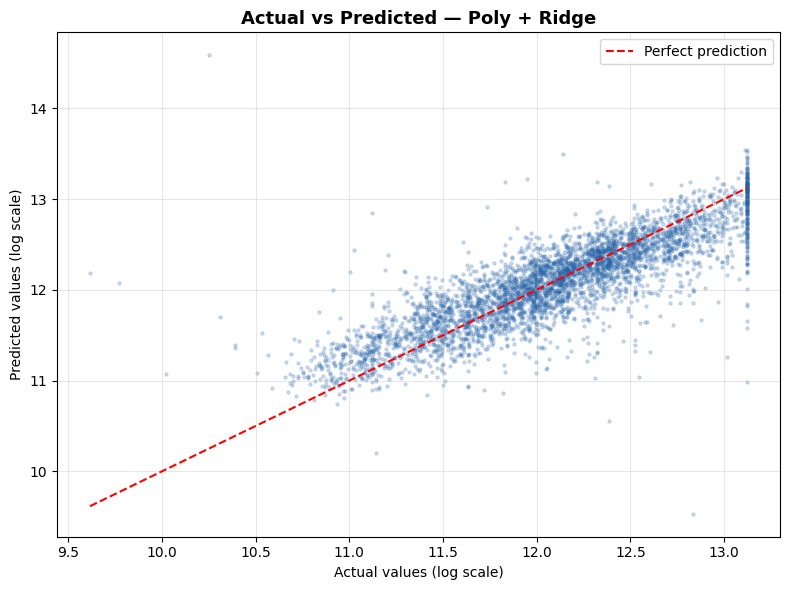

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# Best degree and alpha values  from the GridSearch
best_degree = 3
best_alpha = 1.3895

# Final best pipeline using the identified hyperparameters
final_best_pipeline = Pipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('polynomial', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('scaler',     StandardScaler()),
    ('model',      Ridge(alpha=best_alpha))
])

# Fit this final best pipeline on the full training data
final_best_pipeline.fit(X_train, y_train)

# Fit pipeline for prediction
y_pred = final_best_pipeline.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.2, s=5, color='#2563a8')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linewidth=1.5, linestyle='--', label='Perfect prediction')
ax.set_xlabel('Actual values (log scale)')
ax.set_ylabel('Predicted values (log scale)')
ax.set_title('Actual vs Predicted — Poly + Ridge', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

GridSearch + Polynomial + Lasso Regression  Pipeline

Pipeline

In [ ]:
# Pipeline
lasso_poly_pipe = Pipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('polynomial', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler',     StandardScaler()),
    ('model',      Lasso(tol=0.01, max_iter=10000))
])

GridSearchCV

In [ ]:
# GridSearch
param_grid_lasso = {"polynomial__degree": [1,2,3],'model__alpha': np.logspace(-4, 1, 50)}


In [ ]:
grid_lasso = GridSearchCV(lasso_poly_pipe, param_grid_lasso, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_lasso.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('polynomial',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('model',
                                        Lasso(max_iter=10000, tol=0.01))]),
             n_jobs=-1,
             param_grid={'model__alpha': array([1.00000000e-04, 1.26485522e-04, 1.59985872e-04, 2.02358965e-04,
       2.55954792e-04, 3.23745754e-04, 4....
       7.19685673e-02, 9.10298178e-02, 1.15139540e-01, 1.45634848e-01,
       1.84206997e-01, 2.32995181e-01, 2.94705170e-01, 3.72759372e-01,
       4.71486636e-01, 5.96362332e-01, 7.54312006e-01, 9.54095476e-01,
       1.20679264e+00, 1.52641797e+00, 1.93069773e+00, 2.44205309e+00,
       3.08884360e+00, 3.90693994e+00, 4.94171336e+00, 6.25055193e+00,
       7.90604321e+00, 1.00000000e+01]),
                         'polynomial__degree': [1, 2, 3]},
             scoring='r2', verbose=1)

In [ ]:
print("── Polynomial + Lasso ──")
print(f"Best degree: {grid_lasso.best_params_['polynomial__degree']}")
print(f"Best alpha:  {grid_lasso.best_params_['model__alpha']:.6f}")
print(f"Best CV R²:  {grid_lasso.best_score_:.4f}")
print(f"R² Train:    {grid_lasso.score(X_train, y_train):.4f}")
print(f"R² Test:     {grid_lasso.score(X_test,  y_test):.4f}")

── Polynomial + Lasso ──
Best degree: 3
Best alpha:  0.000655
Best CV R²:  0.7224
R² Train:    0.7356
R² Test:     0.7090


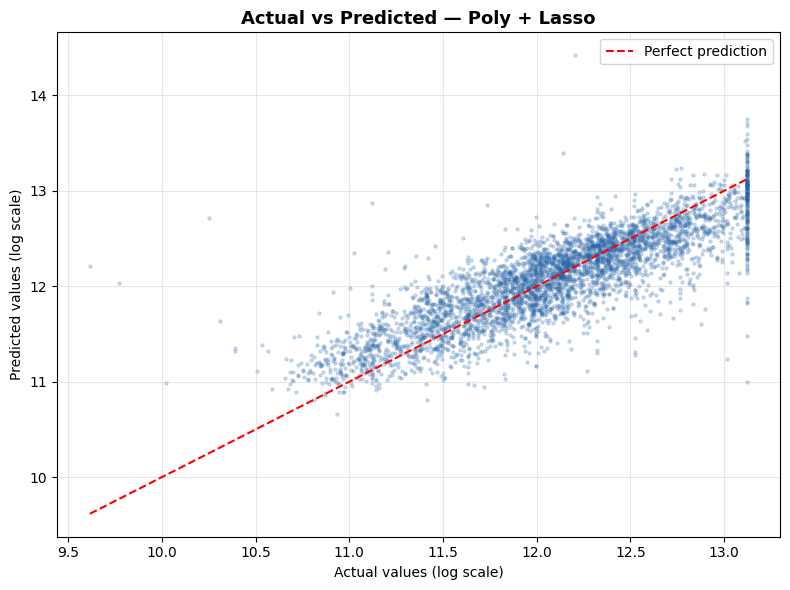

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# Best degree and alpha values  from the GridSearch
best_degree = 3
best_alpha = 0.000655

# Final best pipeline using the identified hyperparameters
final_best_pipeline = Pipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('polynomial', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('scaler',     StandardScaler()),
    ('model',      Lasso(alpha=best_alpha))
])

# Fit this final best pipeline on the full training data
final_best_pipeline.fit(X_train, y_train)

# Fit pipeline for prediction
y_pred = final_best_pipeline.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.2, s=5, color='#2563a8')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linewidth=1.5, linestyle='--', label='Perfect prediction')
ax.set_xlabel('Actual values (log scale)')
ax.set_ylabel('Predicted values (log scale)')
ax.set_title('Actual vs Predicted — Poly + Lasso', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
best_lasso = grid_lasso.best_estimator_
coefs = best_lasso.named_steps['model'].coef_

print(f"Total features:    {len(coefs)}")
print(f"Non-zero features: {(coefs != 0).sum()}")
print(f"Zeroed out:        {(coefs == 0).sum()}")
print(f"% eliminated:      {(coefs == 0).sum() / len(coefs) * 100:.1f}%")

Total features:    454
Non-zero features: 90
Zeroed out:        364
% eliminated:      80.2%


In [ ]:
pd.DataFrame(grid_lasso.cv_results_).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_polynomial__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.180632,0.028441,0.016110,0.006597,0.000100,1,"{'model__alpha': 0.0001, 'polynomial__degree': 1}",0.674364,0.659044,0.676926,0.670602,0.651428,0.666473,0.009697,44
1,22.411856,6.625161,0.018792,0.001696,0.000100,2,"{'model__alpha': 0.0001, 'polynomial__degree': 2}",0.723252,0.710954,0.727190,0.729934,0.575846,0.693435,0.059152,37
2,120.972806,13.070922,0.058189,0.002130,0.000100,3,"{'model__alpha': 0.0001, 'polynomial__degree': 3}",0.696311,0.734895,0.731845,0.745355,0.630615,0.707804,0.041981,24
3,0.119306,0.005928,0.010498,0.000668,0.000126,1,"{'model__alpha': 0.00012648552168552957, 'poly...",0.674361,0.659036,0.676912,0.670596,0.651445,0.666470,0.009689,45
4,11.533849,1.276560,0.025535,0.005020,0.000126,2,"{'model__alpha': 0.00012648552168552957, 'poly...",0.722567,0.709665,0.726516,0.728860,0.579769,0.693475,0.057239,36


In [ ]:
# best lasso estimator
best_lasso_model = grid_lasso.best_estimator_

# feature names from polynomial step
feature_names = best_lasso_model.named_steps['polynomial']\
                                .get_feature_names_out(X_train.columns)

# get coefficients from model step
coefs = best_lasso_model.named_steps['model'].coef_

# create mask for non-zero coefficients
nonzero_mask = coefs != 0

# build dataframe of surviving features
surviving = pd.DataFrame({
    'Feature':     feature_names[nonzero_mask],
    'Coefficient': coefs[nonzero_mask]
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"Total features:    {len(coefs)}")
print(f"Non-zero features: {nonzero_mask.sum()}")
print(f"\nTop 15 surviving features:")
print(surviving.head(15).to_string(index=False))

Total features:    454
Non-zero features: 90

Top 15 surviving features:
                                        Feature  Coefficient
                housing_median_age population^2     0.302389
                                      longitude    -0.278370
                                  median_income     0.271799
                         ocean_proximity_INLAND    -0.209976
                                   population^3    -0.164865
              housing_median_age total_bedrooms     0.159150
                  housing_median_age population    -0.137698
housing_median_age total_bedrooms median_income     0.136654
                  latitude^2 housing_median_age    -0.117942
               housing_median_age median_income     0.114469
                  housing_median_age households     0.106035
                                     latitude^3    -0.105534
       housing_median_age population households    -0.103231
             housing_median_age median_income^2    -0.101099
            

***KEY TAKEAWAYS***

1. Polynomial features improved R² from 0.65 → 0.70+
   confirming non-linearity in the data

2. Lasso beats Ridge on test R² (0.7090 vs 0.6976)
   by eliminating 80% of noisy polynomial features

3. Lasso has smallest train/test gap (0.0266)
   best generalisation of all four models

4. Ridge kept 384 features — more complex model
   yet performed worse on unseen data
   → complexity without selectivity hurts generalisation

5. Poly + Lasso is the best model:
   highest test R², lowest gap, most parsimonious

Model Plots Comparison

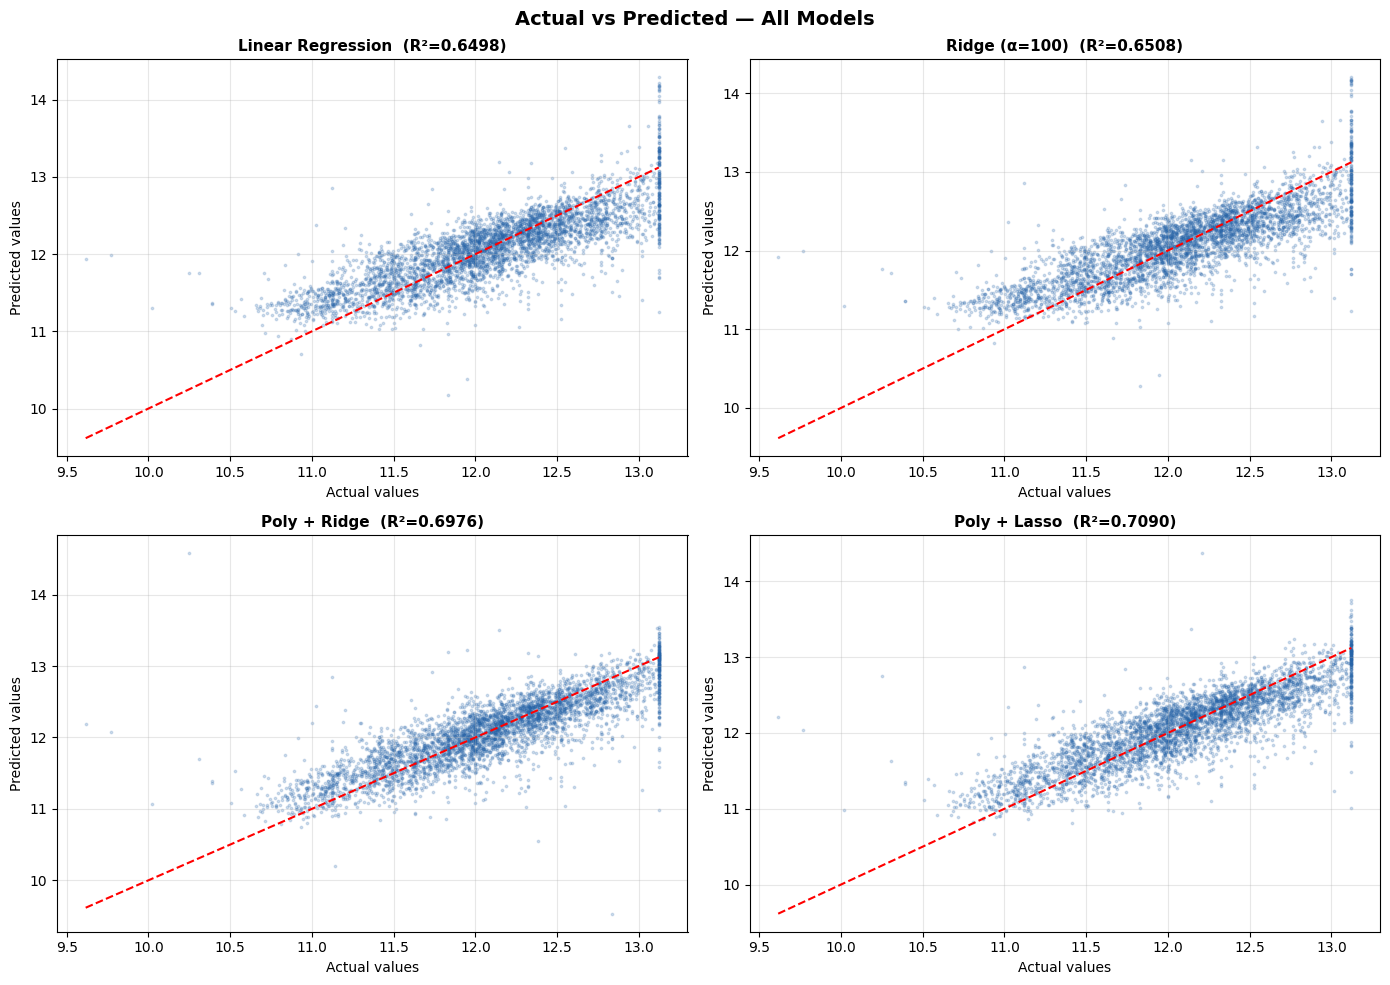

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Actual vs Predicted — All Models', fontsize=14, fontweight='bold')

models = {
    'Linear Regression': lr_pipe,
    'Ridge (α=100)':     ridge_best,
    'Poly + Ridge':      grid_ridge,
    'Poly + Lasso':      grid_lasso
}

for ax, (name, model) in zip(axes.flatten(), models.items()):
    y_pred = model.predict(X_test)
    r2     = model.score(X_test, y_test)

    ax.scatter(y_test, y_pred, alpha=0.2, s=3, color='#2563a8')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color='red', linewidth=1.5, linestyle='--')
    ax.set_title(f'{name}  (R²={r2:.4f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual values')
    ax.set_ylabel('Predicted values')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression': lr_pipe,
    'Ridge (α=100)':     ridge_best,
    'Poly + Ridge':      grid_ridge.best_estimator_,
    'Poly + Lasso':      grid_lasso.best_estimator_
}

print("── Cross Validation Results (KFold=5) ──\n")
for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=kf,
        scoring='r2',
        n_jobs=-1
    )
    print(f"{name}")
    print(f"  Fold scores: {[round(s, 4) for s in scores]}")
    print(f"  Mean R²:     {scores.mean():.4f}")
    print(f"  Std R²:      {scores.std():.4f}")
    print(f"  Range:       {scores.min():.4f} – {scores.max():.4f}")
    print()

── Cross Validation Results (KFold=5) ──

Linear Regression
  Fold scores: [np.float64(0.6636), np.float64(0.6763), np.float64(0.6742), np.float64(0.6656), np.float64(0.6533)]
  Mean R²:     0.6666
  Std R²:      0.0082
  Range:       0.6533 – 0.6763

Ridge (α=100)
  Fold scores: [np.float64(0.6639), np.float64(0.6743), np.float64(0.6733), np.float64(0.6635), np.float64(0.6551)]
  Mean R²:     0.6660
  Std R²:      0.0071
  Range:       0.6551 – 0.6743

Poly + Ridge
  Fold scores: [np.float64(0.6191), np.float64(0.7513), np.float64(0.7483), np.float64(0.6809), np.float64(0.7413)]
  Mean R²:     0.7082
  Std R²:      0.0515
  Range:       0.6191 – 0.7513

Poly + Lasso
  Fold scores: [np.float64(0.7315), np.float64(0.7384), np.float64(0.7346), np.float64(0.7116), np.float64(0.6667)]
  Mean R²:     0.7165
  Std R²:      0.0266
  Range:       0.6667 – 0.7384



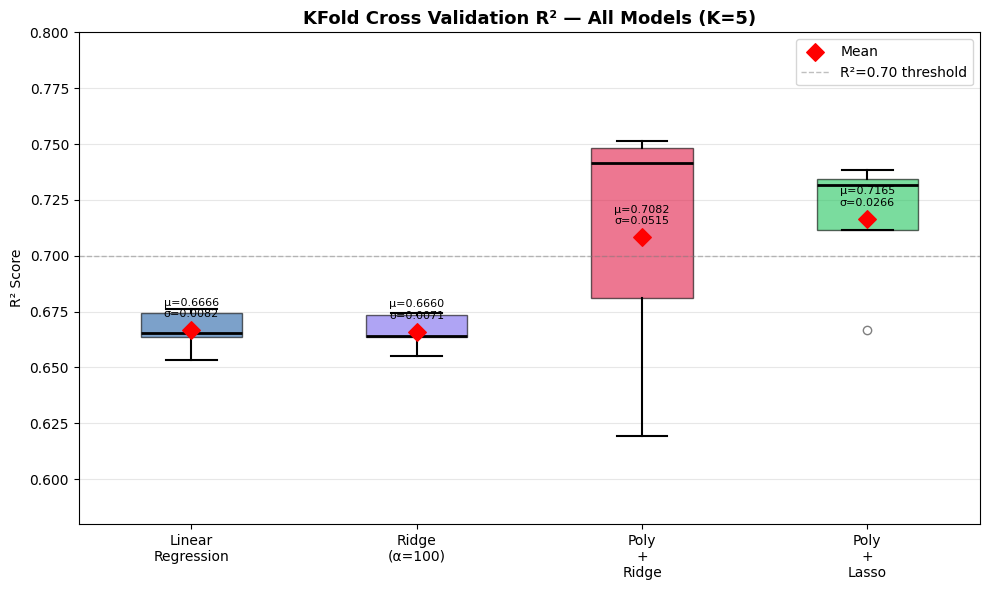

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

all_scores = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=kf, scoring='r2', n_jobs=-1
    )
    all_scores[name] = scores

colors = ['#2563a8', '#7B68EE', '#e11d48', '#22c55e']

bp = ax.boxplot(
    all_scores.values(),
    labels=[k.replace(' ', '\n') for k in all_scores.keys()],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=6, alpha=0.5)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Add mean markers
for i, (name, scores) in enumerate(all_scores.items(), 1):
    ax.scatter(i, np.mean(scores), color='red',
               zorder=5, s=80, marker='D', label='Mean' if i == 1 else '')

# Add R² values as text
for i, (name, scores) in enumerate(all_scores.items(), 1):
    ax.text(i, np.mean(scores) + 0.005,
            f'μ={np.mean(scores):.4f}\nσ={np.std(scores):.4f}',
            ha='center', va='bottom', fontsize=8)

ax.set_title('KFold Cross Validation R² — All Models (K=5)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('R² Score')
ax.set_ylim(0.58, 0.80)
ax.axhline(y=0.70, color='gray', linestyle='--',
           linewidth=1, alpha=0.5, label='R²=0.70 threshold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

***From this KFold analysis***

1. Poly + Ridge looks good on single test set (0.6976)
   but KFold reveals it is unreliable (std=0.0515)
   → single train/test split can be misleading

2. Always use KFold to confirm model stability
   before selecting a final model

3. Poly + Lasso is robust — consistent across
   4 out of 5 folds, with only one weak fold
   likely due to data distribution in that split
4. Linear Regression is stable but weak
5. Ridge (α=100) is most stable but weak

Conclusion: Lasso is the winner!
    

***Section 6- Key Findings***

In [ ]:

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 6 — KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. NON-LINEARITY IS THE BIGGEST MODELLING CHALLENGE
   ─────────────────────────────────────────────────
   Plain Linear Regression and Ridge both achieved
   R² ≈ 0.65 — leaving 35% of variance unexplained.

   Adding polynomial features (degree=3) pushed
   R² to 0.70+ — a +4.7% improvement confirming
   that non-linear interactions between features
   drive house prices in ways linear models miss.

   Key non-linear relationships identified:
   → income vs price:     logarithmic curve
   → households vs price: inverted-U shape
   → latitude³:           cubic geographic effect

2. MEDIAN INCOME IS THE DOMINANT PREDICTOR
   ─────────────────────────────────────────
   Across all models median_income consistently
   had the largest positive coefficient (+0.27–0.32).

   Higher income districts command significantly
   higher prices — robust finding unaffected by
   regularisation or polynomial transformation.

3. GEOGRAPHY ENCODES A COASTAL PREMIUM
   ──────────────────────────────────────
   latitude and longitude were the strongest
   negative coefficients in linear models:

   → Moving north  (higher latitude)  → cheaper
   → Moving east   (higher longitude) → cheaper
   → Coastal/south districts          → premium

   Confirmed visually by the geographic scatter
   plot showing yellow clusters hugging the coast.

4. HOUSING AGE IS A HIDDEN INTERACTIVE FEATURE
   ──────────────────────────────────────────────
   In Linear Regression: housing_median_age ≈ 0.03
   (appeared almost irrelevant)

   In Poly + Lasso top 15 features:
   housing_median_age appeared in 9 interactions:
   → age × population²
   → age × total_bedrooms
   → age × median_income
   → age × bedrooms × income (3-way interaction)

   Older established neighborhoods command a premium
   — but only when combined with other factors.
   This effect is invisible to linear models.

5. LASSO OUTPERFORMS RIDGE WITH POLYNOMIAL FEATURES
   ──────────────────────────────────────────────────
   Poly + Ridge: kept 384/454 features → R²=0.6976
   Poly + Lasso: kept  90/454 features → R²=0.7090

   Lasso eliminated 80% of polynomial features
   as noise — achieving higher test R² with a
   simpler, more interpretable model.

   → Complexity without selectivity hurts
     generalisation (Ridge lesson)
   → Feature selection improves both accuracy
     and interpretability (Lasso lesson)

6. REGULARISATION MATTERS MORE WITH POLYNOMIAL FEATURES
   ───────────────────────────────────────────────────────
   Plain Ridge vs Linear: R² difference = +0.0009
   Poly + Lasso vs Poly + Ridge: R² diff = +0.0114

   Regularisation becomes critical when the feature
   space explodes from 12 → 454 columns. Without it,
   the model overfits badly to noisy interactions.
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 6 — KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. NON-LINEARITY IS THE BIGGEST MODELLING CHALLENGE
   ─────────────────────────────────────────────────
   Plain Linear Regression and Ridge both achieved
   R² ≈ 0.65 — leaving 35% of variance unexplained.
   
   Adding polynomial features (degree=3) pushed
   R² to 0.70+ — a +4.7% improvement confirming
   that non-linear interactions between features
   drive house prices in ways linear models miss.
   
   Key non-linear relationships identified:
   → income vs price:     logarithmic curve
   → households vs price: inverted-U shape
   → latitude³:           cubic geographic effect

2. MEDIAN INCOME IS THE DOMINANT PREDICTOR
   ─────────────────────────────────────────
   Across all models median_income consistently
   had the largest positive coefficient (+0.27–0.32).
   
   Higher income districts command significantly
   higher prices — robust finding unaff

***Section 7 — Limitations & Next Steps***

In [ ]:

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 7 — LIMITATIONS & NEXT STEPS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

LIMITATIONS
───────────

1. $500,001 CENSUS CAP
   All districts with true values above $500k
   were recorded as $500,001 — affecting ~4.7%
   of observations.

   Impact:
   → Model cannot predict true values above cap
   → Visible as vertical cluster in all plots
   → Artificially compresses R² for top districts

   Evidence: dense vertical line at x=13.1
   in all four actual vs predicted plots.

2. REMAINING UNEXPLAINED VARIANCE (R²=0.709)
   Even the best model (Poly + Lasso) leaves
   29.1% of price variance unexplained.

   Missing features likely responsible:
   → School district quality
   → Crime rates
   → Distance to employment centres
   → Zoning regulations
   → Neighbourhood amenities

3. TEMPORAL OBSOLESCENCE
   Data from 1990 Census — 35 years old.
   California housing market has changed
   dramatically since then:
   → Post dot-com boom (2000)
   → Post 2008 financial crisis
   → Post COVID remote work shift

   Model cannot be used for current predictions
   without significant recalibration.

4. OVERFITTING WITH POLYNOMIAL FEATURES
   Poly + Ridge train/test gap = 0.0577
   Poly + Lasso train/test gap = 0.0266

   Even the best model shows some overfitting —
   degree=3 generates 454 features from 12,
   risking memorisation of training patterns.

5. HETEROSCEDASTICITY
   Model residuals spread increases at higher
   predicted values — the model is less reliable
   for expensive districts than cheap ones.

   OLS assumes constant variance — this violation
   means confidence intervals are unreliable
   at price extremes.

6. SPATIAL AUTOCORRELATION IGNORED
   Nearby districts share unobserved characteristics
   (school districts, neighbourhood effects).
   Standard regression assumes independent errors
   — a spatial model would better account for this.

NEXT STEPS
──────────

1. TRY TREE-BASED MODELS
   Random Forest and Gradient Boosting (XGBoost,
   LightGBM) natively handle:
   → Non-linearity without polynomial features
   → Feature interactions automatically
   → Heteroscedasticity more robustly

   Expected R² improvement: 0.70 → 0.82+

2. ENGINEER BETTER FEATURES
   rooms_per_household       = total_rooms / households
   bedrooms_per_room         = total_bedrooms / total_rooms
   population_per_household  = population / households
   distance_to_coast         = computed from lat/lon
   distance_to_city_centre   = SF, LA, San Diego

3. ADDRESS THE CENSUS CAP
   Option A: drop capped rows (df[df.median_house_value < 500001])
   Option B: treat as censored data — Tobit regression
   Option C: report metrics separately for capped
             vs non-capped districts

4. ADD EXTERNAL DATA SOURCES
   → School ratings (GreatSchools API)
   → Crime statistics
   → Walkability scores
   → Unemployment rates by district

5. USE SPATIAL REGRESSION
   Geographically Weighted Regression (GWR)
   allows coefficients to vary by location —
   capturing the fact that income predicts
   price differently in LA vs Central Valley.

""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 7 — LIMITATIONS & NEXT STEPS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

LIMITATIONS
───────────

1. $500,001 CENSUS CAP
   All districts with true values above $500k
   were recorded as $500,001 — affecting ~4.7%
   of observations.
   
   Impact:
   → Model cannot predict true values above cap
   → Visible as vertical cluster in all plots
   → Artificially compresses R² for top districts
   
   Evidence: dense vertical line at x=13.1
   in all four actual vs predicted plots.

2. REMAINING UNEXPLAINED VARIANCE (R²=0.709)
   Even the best model (Poly + Lasso) leaves
   29.1% of price variance unexplained.
   
   Missing features likely responsible:
   → School district quality
   → Crime rates
   → Distance to employment centres
   → Zoning regulations
   → Neighbourhood amenities

3. TEMPORAL OBSOLESCENCE
   Data from 1990 Census — 35 years old.
   California housing market has changed
   dramatically since then:
   → Pos

Copyright @ IBM Corporation. All rights reserved.
